# Problem 3 — Formula-term Residual GRU (T/W FLOW as Qin)

本 notebook 按“公式分项特征 + 残差 GRU”的思路实现第三题。

预测对象是 **出厂水浊度 NTU / 清水处理后水浊度 NTU**，不是 `FILT. NTU`。

核心：

```text
y = future_NTU - current_NTU
pred_NTU = current_NTU + pred_delta_NTU
Qin = T/W FLOW
```

In [2]:
# =========================
# 0. Global configuration
# =========================

from pathlib import Path

POSSIBLE_DATA_PATHS = [
    Path(r"E:\桌面\亚太杯\2026-Asia-Pacific-cup\data\merged.xlsx"),
    Path(r"E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx"),
    Path("data/merged.xlsx"),
    Path("merged.xlsx"),
    Path("../data/merged.xlsx"),
]

OUTPUT_DIR = Path("outputs/problem3_formula_gru/TW_Qin")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MANUAL_DATETIME_COL = None
MANUAL_DATE_COL = "DATE"
MANUAL_TIME_COL = "TIME"
ALLOW_DATE_ONLY = False

TARGET_OVERRIDE = None

QIN_MODE = "TW"
QIN_COL = "T/W FLOW"

DT_HOURS = 2.0
EPS = 1e-6

LOOKBACK = 12
HORIZON = 6
HORIZON_HOURS = [2, 4, 6, 8, 10, 12]
EXPECTED_FREQ_HOURS = 2

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 15
LEARNING_RATE = 1e-3

HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.10

SEED = 42

REQUESTED_DATES = ["2026-02-01", "2026-02-10", "2026-02-20"]
REQUESTED_TIMES = ["07:00", "09:00", "11:00", "13:00", "15:00", "17:00", "19:00"]

NATIVE_GRID_START_TIME = "07:00"
NATIVE_BASE_TOLERANCE_HOURS = 1.1

USE_GAP_AWARE_SEQUENCES = True
ALLOW_ROW_ORDER_FALLBACK = True

print("Qin mode:", QIN_MODE, "| Qin column:", QIN_COL)
print("Output directory:", OUTPUT_DIR.resolve())

Qin mode: TW | Qin column: T/W FLOW
Output directory: E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes\p3\outputs\problem3_formula_gru\TW_Qin


In [3]:
# =========================
# 1. Imports and seed
# =========================

import os
import math
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 2. Load data and reconstruct datetime

In [4]:
# =========================
# 2. Load data and robust datetime reconstruction
# =========================

def find_data_path(possible_paths):
    for p in possible_paths:
        if p.exists():
            return p
    raise FileNotFoundError(
        "merged.xlsx not found. Please put it at one of: "
        + ", ".join(str(p) for p in possible_paths)
    )

def parse_excel_or_regular_date(s):
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().mean() >= 0.70:
        values = numeric.dropna()
        if len(values) > 0 and values.between(20000, 60000).mean() >= 0.70:
            return pd.to_datetime(numeric, unit="D", origin="1899-12-30", errors="coerce")
    return pd.to_datetime(s, errors="coerce")

def parse_time_to_timedelta(s):
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().mean() >= 0.70:
        vals = numeric.dropna()
        if len(vals) > 0:
            min_v, max_v = vals.min(), vals.max()
            if min_v >= 0 and max_v <= 1:
                return pd.to_timedelta(numeric, unit="D")
            if min_v >= 0 and max_v <= 24:
                return pd.to_timedelta(numeric, unit="h")
            if min_v >= 0 and max_v <= 2359:
                as_int = numeric.round().astype("Int64")
                hours = (as_int // 100).astype("float")
                minutes = (as_int % 100).astype("float")
                valid = (hours >= 0) & (hours <= 23) & (minutes >= 0) & (minutes <= 59)
                out = pd.Series(pd.NaT, index=s.index, dtype="timedelta64[ns]")
                out.loc[valid] = (
                    pd.to_timedelta(hours.loc[valid], unit="h") +
                    pd.to_timedelta(minutes.loc[valid], unit="m")
                )
                if out.notna().mean() >= 0.70:
                    return out

    text = s.astype(str).str.strip()
    parsed = pd.to_datetime(text, errors="coerce")
    return (
        pd.to_timedelta(parsed.dt.hour, unit="h") +
        pd.to_timedelta(parsed.dt.minute, unit="m") +
        pd.to_timedelta(parsed.dt.second, unit="s")
    )

def build_datetime_column(df):
    cols = list(df.columns)
    upper_map = {c: str(c).upper().strip() for c in cols}

    if MANUAL_DATETIME_COL is not None:
        parsed = pd.to_datetime(df[MANUAL_DATETIME_COL], errors="coerce")
        if parsed.notna().mean() < 0.70:
            raise ValueError("Manual datetime column cannot be parsed.")
        return parsed, MANUAL_DATETIME_COL

    if MANUAL_DATE_COL is not None and MANUAL_TIME_COL is not None:
        date_part = parse_excel_or_regular_date(df[MANUAL_DATE_COL]).dt.normalize()
        time_delta = parse_time_to_timedelta(df[MANUAL_TIME_COL])
        combined = date_part + time_delta
        if combined.notna().mean() < 0.70:
            raise ValueError("Manual DATE + TIME cannot be parsed.")
        return combined, f"{MANUAL_DATE_COL} + {MANUAL_TIME_COL}"

    date_keywords = ["DATE", "日期", "DAY", "日"]
    time_keywords = ["TIME", "时间", "HOUR", "小时", "时刻"]

    date_cols = [c for c in cols if any(k in upper_map[c] for k in date_keywords)]
    time_cols = [c for c in cols if any(k in upper_map[c] for k in time_keywords)]

    candidates = []
    for d in date_cols:
        for t in time_cols:
            if d == t:
                continue
            date_part = parse_excel_or_regular_date(df[d]).dt.normalize()
            time_delta = parse_time_to_timedelta(df[t])
            combined = date_part + time_delta
            candidates.append((combined.notna().mean(), combined.dropna().dt.strftime("%H:%M").nunique(), d, t, combined))

    candidates = sorted(candidates, key=lambda x: (x[0], x[1]), reverse=True)
    for valid_rate, unique_times, d, t, combined in candidates:
        if valid_rate >= 0.70 and unique_times > 1:
            return combined, f"{d} + {t}"

    for c in cols:
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().mean() >= 0.70:
            return parsed, c

    raise ValueError("Cannot detect datetime column.")

def validate_datetime_resolution(df):
    dt = pd.to_datetime(df["DATETIME"])
    print("Unique time-of-day count:", dt.dt.strftime("%H:%M").nunique())
    print("\\nMost common time differences:")
    display(dt.sort_values().diff().value_counts().head(5).to_frame("count"))

data_path = find_data_path(POSSIBLE_DATA_PATHS)
print("Reading:", data_path.resolve())

data = pd.read_excel(data_path)
data.columns = [str(c).strip() for c in data.columns]

dt, dt_source = build_datetime_column(data)
data["DATETIME"] = dt

data = (
    data.dropna(subset=["DATETIME"])
        .sort_values("DATETIME")
        .drop_duplicates(subset=["DATETIME"], keep="first")
        .reset_index(drop=True)
)

print("Datetime source:", dt_source)
print("Shape:", data.shape)
print("Time range:", data["DATETIME"].min(), "to", data["DATETIME"].max())
validate_datetime_resolution(data)

print("\\nColumns:")
print(data.columns.tolist())

Reading: E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
Datetime source: DATE + TIME
Shape: (5460, 19)
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00
Unique time-of-day count: 12
\nMost common time differences:


,count
DATETIME,
0 days 02:00:00,5459


\nColumns:
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW', 'DATETIME']


## 3. Detect target and construct formula-term features

In [5]:
# =========================
# 3. Correct target and formula-term features
# =========================

def norm_col(c):
    return str(c).upper().strip().replace(" ", "").replace("_", "").replace("-", "").replace("/", "").replace(".", "")

def detect_p3_target(df, override=None):
    cols = list(df.columns)

    if override is not None:
        if override not in df.columns:
            raise KeyError(f"TARGET_OVERRIDE not found: {override}")
        return override

    preferred = [
        "C/W NTU", "CW NTU", "CLEAR WATER NTU", "TREATED WATER NTU",
        "OUTLET NTU", "FINAL NTU", "EFFLUENT NTU",
        "出厂水浊度", "清水浊度", "处理后水浊度", "清水/处理后水浊度",
    ]
    norm_to_col = {norm_col(c): c for c in cols}
    for p in preferred:
        if norm_col(p) in norm_to_col:
            return norm_to_col[norm_col(p)]

    for c in ["NTU", "NTU.1", "NTU_1", "NTU (第二处)", "NTU第二处"]:
        if c in cols:
            return c

    ntu_cols = [
        c for c in cols
        if ("NTU" in str(c).upper() or "浊" in str(c))
        and c not in ["R/W NTU", "FILT. NTU"]
    ]

    if "FILT. NTU" in cols and ntu_cols:
        filt_idx = cols.index("FILT. NTU")
        after_filt = [c for c in ntu_cols if cols.index(c) > filt_idx]
        if after_filt:
            return after_filt[0]

    if ntu_cols:
        return ntu_cols[-1]

    raise ValueError("Cannot detect P3 target. Set TARGET_OVERRIDE manually.")

TARGET = detect_p3_target(data, TARGET_OVERRIDE)

if TARGET in ["FILT. NTU", "R/W NTU"]:
    raise ValueError(f"Wrong target detected: {TARGET}. P3 target must be outlet/treated-water NTU.")

print("Detected P3 target:", TARGET)
print("\\nNTU-related columns:")
for c in data.columns:
    if "NTU" in str(c).upper() or "浊" in str(c):
        print("  ", c, "<-- TARGET" if c == TARGET else "")

REQUIRED_COLS = [
    TARGET,
    "FILT. NTU",
    "C/W WELL LEVEL",
    "R/W FLOW",
    "T/W FLOW",
]

missing = [c for c in REQUIRED_COLS if c not in data.columns]
if missing:
    raise KeyError("Missing columns required for formula-term GRU: " + str(missing))

data_pre = data.copy()

for c in REQUIRED_COLS:
    data_pre[c] = pd.to_numeric(data_pre[c], errors="coerce")
    data_pre[c] = (
        data_pre[c]
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

well_level = data_pre["C/W WELL LEVEL"].astype(float)
well_level_safe = well_level.where(well_level.abs() > EPS, np.nan)
well_level_safe = well_level_safe.interpolate(method="linear", limit_direction="both").ffill().bfill()
well_level_safe = well_level_safe.abs() + EPS

current_ntu = data_pre[TARGET].astype(float)
filt_ntu = data_pre["FILT. NTU"].astype(float)
rw_flow = data_pre["R/W FLOW"].astype(float)
tw_flow = data_pre["T/W FLOW"].astype(float)

qin = rw_flow if QIN_MODE == "RW" else tw_flow
qout = tw_flow

data_pre["current_NTU"] = current_ntu
data_pre["inflow_term"] = DT_HOURS * qin * filt_ntu / well_level_safe
data_pre["outflow_term"] = DT_HOURS * qout * current_ntu / well_level_safe
data_pre["HRT_PROXY"] = well_level_safe / (qout.abs() + EPS)
data_pre["WELL_LEVEL_CHANGE"] = well_level.diff().fillna(0.0)

FEATURES = [
    "current_NTU",
    "inflow_term",
    "outflow_term",
    "HRT_PROXY",
    "WELL_LEVEL_CHANGE",
    "FILT. NTU",
    "R/W FLOW",
    "T/W FLOW",
]

print("\\nQin mode:", QIN_MODE)
print("Qin column:", QIN_COL)
print("Target:", TARGET)
print("Features:", FEATURES)
print("Expected tensor shape: [batch_size, 12, 8]")

print("\\nMissing values after feature construction:")
display(data_pre[["DATETIME", TARGET] + FEATURES].isna().sum().to_frame("missing_count"))

display(data_pre[["DATETIME", TARGET] + FEATURES].head())

Detected P3 target: NTU
\nNTU-related columns:
   R/W NTU 
   FILT. NTU 
   NTU <-- TARGET
\nQin mode: TW
Qin column: T/W FLOW
Target: NTU
Features: ['current_NTU', 'inflow_term', 'outflow_term', 'HRT_PROXY', 'WELL_LEVEL_CHANGE', 'FILT. NTU', 'R/W FLOW', 'T/W FLOW']
Expected tensor shape: [batch_size, 12, 8]
\nMissing values after feature construction:


,missing_count
DATETIME,0
NTU,0
current_NTU,0
inflow_term,0
outflow_term,0
HRT_PROXY,0
WELL_LEVEL_CHANGE,0
FILT. NTU,0
R/W FLOW,0
T/W FLOW,0


,DATETIME,NTU,current_NTU,inflow_term,outflow_term,HRT_PROXY,WELL_LEVEL_CHANGE,FILT. NTU,R/W FLOW,T/W FLOW
0,2025-01-01 07:00:00,0.12,0.12,0.892146,2.676439,0.089671,0.00,0.04,45.3,42.6
1,2025-01-01 09:00:00,0.12,0.12,1.118110,2.683464,0.089437,-0.01,0.05,45.2,42.6
2,2025-01-01 11:00:00,0.12,0.12,1.120735,2.689763,0.089227,0.00,0.05,44.9,42.7
3,2025-01-01 13:00:00,0.11,0.11,1.181564,2.599441,0.084634,-0.23,0.05,44.9,42.3
4,2025-01-01 15:00:00,0.11,0.11,1.187151,2.611731,0.084235,0.00,0.05,44.5,42.5


## 4. Chronological split, scaling and residual sequences

In [6]:
# =========================
# 4. Split, scaling, residual sequence construction
# =========================

full_df = data_pre[["DATETIME", TARGET] + FEATURES].copy()
full_df = full_df.sort_values("DATETIME").reset_index(drop=True)

n = len(full_df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = full_df.iloc[:train_end].copy().reset_index(drop=True)
val_df = full_df.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df = full_df.iloc[val_end:].copy().reset_index(drop=True)

print("Total rows:", n)
print("Train rows:", len(train_df), train_df["DATETIME"].min(), "to", train_df["DATETIME"].max())
print("Val rows:", len(val_df), val_df["DATETIME"].min(), "to", val_df["DATETIME"].max())
print("Test rows:", len(test_df), test_df["DATETIME"].min(), "to", test_df["DATETIME"].max())

feature_scaler = StandardScaler()
delta_scaler = StandardScaler()
feature_scaler.fit(train_df[FEATURES])

def make_residual_sequences(raw_df, feature_scaler, gap_aware=True):
    df = raw_df.copy().reset_index(drop=True)
    df["DATETIME"] = pd.to_datetime(df["DATETIME"])

    scaled_features = feature_scaler.transform(df[FEATURES]).astype(np.float32)
    target_values = df[TARGET].to_numpy(dtype=np.float32)
    times = pd.to_datetime(df["DATETIME"]).to_numpy()

    if gap_aware:
        gaps = df["DATETIME"].diff()
        segment_id = (gaps > pd.Timedelta(hours=EXPECTED_FREQ_HOURS * 1.5)).cumsum().to_numpy()
    else:
        segment_id = np.zeros(len(df), dtype=int)

    X_list, y_delta_list, current_list, base_times, target_times = [], [], [], [], []

    for seg_id in np.unique(segment_id):
        idx = np.where(segment_id == seg_id)[0]
        if len(idx) < LOOKBACK + HORIZON:
            continue

        for local_end in range(LOOKBACK - 1, len(idx) - HORIZON):
            end_idx = idx[local_end]
            hist_idx = idx[local_end - LOOKBACK + 1: local_end + 1]
            fut_idx = idx[local_end + 1: local_end + 1 + HORIZON]

            current_c = target_values[end_idx]
            future_c = target_values[fut_idx]
            delta = future_c - current_c

            X_list.append(scaled_features[hist_idx])
            y_delta_list.append(delta)
            current_list.append(current_c)
            base_times.append(times[end_idx])
            target_times.append(times[fut_idx])

    if len(X_list) == 0:
        return (
            np.empty((0, LOOKBACK, len(FEATURES)), dtype=np.float32),
            np.empty((0, HORIZON), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
            np.array([]),
            np.empty((0, HORIZON), dtype="datetime64[ns]"),
        )

    return (
        np.stack(X_list).astype(np.float32),
        np.stack(y_delta_list).astype(np.float32),
        np.array(current_list, dtype=np.float32),
        np.array(base_times),
        np.stack(target_times),
    )

X_train, y_train_delta_raw, current_train, base_train_times, target_train_times = make_residual_sequences(train_df, feature_scaler, USE_GAP_AWARE_SEQUENCES)
X_val, y_val_delta_raw, current_val, base_val_times, target_val_times = make_residual_sequences(val_df, feature_scaler, USE_GAP_AWARE_SEQUENCES)
X_test, y_test_delta_raw, current_test, base_test_times, target_test_times = make_residual_sequences(test_df, feature_scaler, USE_GAP_AWARE_SEQUENCES)

if len(X_train) == 0 and ALLOW_ROW_ORDER_FALLBACK:
    print("Gap-aware sequence construction failed. Falling back to row-order sequences.")
    X_train, y_train_delta_raw, current_train, base_train_times, target_train_times = make_residual_sequences(train_df, feature_scaler, False)
    X_val, y_val_delta_raw, current_val, base_val_times, target_val_times = make_residual_sequences(val_df, feature_scaler, False)
    X_test, y_test_delta_raw, current_test, base_test_times, target_test_times = make_residual_sequences(test_df, feature_scaler, False)

if len(X_train) == 0:
    raise ValueError("No training sequences created.")

delta_scaler.fit(y_train_delta_raw.reshape(-1, 1))

def scale_delta(y_delta):
    shape = y_delta.shape
    return delta_scaler.transform(y_delta.reshape(-1, 1)).reshape(shape).astype(np.float32)

def inverse_delta(y_scaled):
    shape = y_scaled.shape
    return delta_scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(shape)

y_train = scale_delta(y_train_delta_raw)
y_val = scale_delta(y_val_delta_raw)
y_test = scale_delta(y_test_delta_raw)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

display(pd.DataFrame({"train_delta_flat": y_train_delta_raw.reshape(-1)}).describe())

Total rows: 5460
Train rows: 3821 2025-01-01 07:00:00 to 2025-11-15 15:00:00
Val rows: 820 2025-11-15 17:00:00 to 2026-01-22 23:00:00
Test rows: 819 2026-01-23 01:00:00 to 2026-04-01 05:00:00
X_train: (3804, 12, 8) y_train: (3804, 6)
X_val: (803, 12, 8) y_val: (803, 6)
X_test: (802, 12, 8) y_test: (802, 6)


,train_delta_flat
count,22824.000000
mean,0.000258
std,0.530547
min,-11.620000
25%,-0.010000
50%,0.000000
75%,0.020000
max,10.980000


## 5. Dataset, model and training

ResidualGRU(
  (gru): GRU(8, 64, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)
Epoch 001 | train_loss=0.127687 | val_loss=0.061015
Epoch 010 | train_loss=0.103768 | val_loss=0.059429
Early stopping at epoch 19. Best val_loss=0.057575


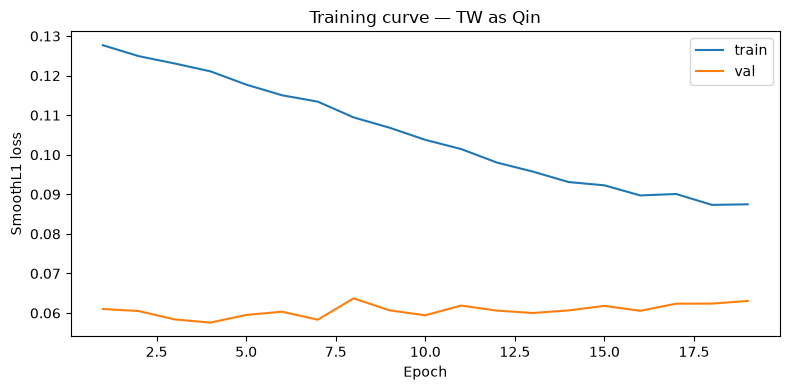

Saved training history to: outputs\problem3_formula_gru\TW_Qin\training_history.xlsx


In [7]:
# =========================
# 5. Dataset, model, training
# =========================

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SequenceDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SequenceDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SequenceDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

class ResidualGRU(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.1, output_size=6):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=effective_dropout,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_hidden = gru_out[:, -1, :]
        last_hidden = self.dropout(last_hidden)
        return self.fc(last_hidden)

model = ResidualGRU(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    output_size=HORIZON,
).to(device)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print(model)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        pred = model(xb)
        loss = criterion(pred, yb)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        n += bs

    return total_loss / max(n, 1)

best_val_loss = float("inf")
best_state = None
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, optimizer)
    val_loss = run_epoch(model, val_loader, optimizer=None)

    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    if val_loss < best_val_loss - 1e-8:
        best_val_loss = val_loss
        best_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.6f}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / "training_history.xlsx"
history_df.to_excel(history_path, index=False)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("SmoothL1 loss")
plt.title(f"Training curve — {QIN_MODE} as Qin")
plt.legend()
plt.tight_layout()
plt.show()

print("Saved training history to:", history_path)

## 6. Evaluation: residual GRU vs persistence

In [8]:
# =========================
# 6. Evaluation
# =========================

def predict_loader(model, loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())

    return np.vstack(preds), np.vstack(trues)

def safe_corr(a, b, method="pearson"):
    a = pd.Series(np.asarray(a).reshape(-1))
    b = pd.Series(np.asarray(b).reshape(-1))
    valid = a.notna() & b.notna()
    a = a[valid]
    b = b[valid]
    if len(a) < 3:
        return np.nan
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return a.corr(b, method=method)

def direction_accuracy(true_delta, pred_delta):
    true_s = np.sign(np.asarray(true_delta).reshape(-1))
    pred_s = np.sign(np.asarray(pred_delta).reshape(-1))
    return np.mean(true_s == pred_s)

def build_metrics(y_true_ntu, y_pred_ntu, y_true_delta, y_pred_delta, model_name):
    rows = []

    for i, hour in enumerate(HORIZON_HOURS):
        yt = y_true_ntu[:, i]
        yp = y_pred_ntu[:, i]
        dt = y_true_delta[:, i]
        dp = y_pred_delta[:, i]

        rows.append({
            "qin_mode": QIN_MODE,
            "model": model_name,
            "horizon": f"t+{i+1}",
            "horizon_hour": hour,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": math.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
            "NTU_Pearson": safe_corr(yt, yp, "pearson"),
            "NTU_Spearman": safe_corr(yt, yp, "spearman"),
            "Delta_Pearson": safe_corr(dt, dp, "pearson"),
            "Delta_Spearman": safe_corr(dt, dp, "spearman"),
            "Direction_Accuracy": direction_accuracy(dt, dp),
        })

    rows.append({
        "qin_mode": QIN_MODE,
        "model": model_name,
        "horizon": "overall",
        "horizon_hour": "2-12",
        "MAE": mean_absolute_error(y_true_ntu.reshape(-1), y_pred_ntu.reshape(-1)),
        "RMSE": math.sqrt(mean_squared_error(y_true_ntu.reshape(-1), y_pred_ntu.reshape(-1))),
        "R2": r2_score(y_true_ntu.reshape(-1), y_pred_ntu.reshape(-1)),
        "NTU_Pearson": safe_corr(y_true_ntu, y_pred_ntu, "pearson"),
        "NTU_Spearman": safe_corr(y_true_ntu, y_pred_ntu, "spearman"),
        "Delta_Pearson": safe_corr(y_true_delta, y_pred_delta, "pearson"),
        "Delta_Spearman": safe_corr(y_true_delta, y_pred_delta, "spearman"),
        "Direction_Accuracy": direction_accuracy(y_true_delta, y_pred_delta),
    })

    return pd.DataFrame(rows)

y_pred_delta_scaled, y_true_delta_scaled = predict_loader(model, test_loader)

pred_delta_gru = inverse_delta(y_pred_delta_scaled)
true_delta = inverse_delta(y_true_delta_scaled)

true_ntu = current_test.reshape(-1, 1) + true_delta
pred_ntu_gru = current_test.reshape(-1, 1) + pred_delta_gru
pred_ntu_gru = np.clip(pred_ntu_gru, 0, None)

pred_delta_persistence = np.zeros_like(true_delta)
pred_ntu_persistence = np.repeat(current_test.reshape(-1, 1), HORIZON, axis=1)
pred_ntu_persistence = np.clip(pred_ntu_persistence, 0, None)

metrics_persistence = build_metrics(true_ntu, pred_ntu_persistence, true_delta, pred_delta_persistence, "Persistence")
metrics_gru = build_metrics(true_ntu, pred_ntu_gru, true_delta, pred_delta_gru, "Formula_Residual_GRU")

metrics_comparison_df = pd.concat([metrics_persistence, metrics_gru], axis=0).reset_index(drop=True)

display(metrics_comparison_df)

metrics_path = OUTPUT_DIR / "metrics_comparison.xlsx"
metrics_comparison_df.to_excel(metrics_path, index=False)
print("Saved metrics to:", metrics_path)

rows = []
for sample_idx in range(len(current_test)):
    for h_idx, hour in enumerate(HORIZON_HOURS):
        rows.append({
            "qin_mode": QIN_MODE,
            "sample_idx": sample_idx,
            "base_time": pd.Timestamp(base_test_times[sample_idx]),
            "target_time": pd.Timestamp(target_test_times[sample_idx, h_idx]),
            "horizon": f"t+{h_idx+1}",
            "horizon_hour": hour,
            "current_NTU": current_test[sample_idx],
            "true_NTU": true_ntu[sample_idx, h_idx],
            "true_delta_NTU": true_delta[sample_idx, h_idx],
            "pred_NTU_gru": pred_ntu_gru[sample_idx, h_idx],
            "pred_delta_gru": pred_delta_gru[sample_idx, h_idx],
            "pred_NTU_persistence": pred_ntu_persistence[sample_idx, h_idx],
            "pred_delta_persistence": 0.0,
        })

test_predictions_df = pd.DataFrame(rows)
display(test_predictions_df.head())

test_pred_path = OUTPUT_DIR / "test_predictions_long.xlsx"
test_predictions_df.to_excel(test_pred_path, index=False)
print("Saved test predictions to:", test_pred_path)

,qin_mode,model,horizon,horizon_hour,MAE,RMSE,R2,NTU_Pearson,NTU_Spearman,Delta_Pearson,Delta_Spearman,Direction_Accuracy
0,TW,Persistence,t+1,2,0.010848,0.063013,0.850730,0.925352,0.987600,NaN,NaN,0.301746
1,TW,Persistence,t+2,4,0.018217,0.089337,0.700011,0.849967,0.975394,NaN,NaN,0.197007
2,TW,Persistence,t+3,6,0.021424,0.093669,0.670271,0.835079,0.965152,NaN,NaN,0.149626
3,TW,Persistence,t+4,8,0.021498,0.085411,0.725941,0.862899,0.955387,NaN,NaN,0.122195
4,TW,Persistence,t+5,10,0.022394,0.082204,0.746232,0.873027,0.947125,NaN,NaN,0.119701
5,TW,Persistence,t+6,12,0.026631,0.096904,0.647623,0.823622,0.938184,NaN,NaN,0.100998
6,TW,Persistence,overall,2-12,0.020169,0.085799,0.723446,0.861652,0.961467,NaN,NaN,0.165212
7,TW,Formula_Residual_GRU,t+1,2,0.019448,0.063049,0.850559,0.927970,0.983620,0.169702,-0.094857,0.503741
8,TW,Formula_Residual_GRU,t+2,4,0.025591,0.086459,0.719030,0.860359,0.969475,0.300976,0.054447,0.554863
9,TW,Formula_Residual_GRU,t+3,6,0.030413,0.090947,0.689156,0.842304,0.958325,0.300811,0.138832,0.632170


Saved metrics to: outputs\problem3_formula_gru\TW_Qin\metrics_comparison.xlsx


,qin_mode,sample_idx,base_time,target_time,horizon,horizon_hour,current_NTU,true_NTU,true_delta_NTU,pred_NTU_gru,pred_delta_gru,pred_NTU_persistence,pred_delta_persistence
0,TW,0,2026-01-23 23:00:00,2026-01-24 01:00:00,t+1,2,0.28,0.28,0.00,0.291127,0.011127,0.28,0.0
1,TW,0,2026-01-23 23:00:00,2026-01-24 03:00:00,t+2,4,0.28,0.27,-0.01,0.293042,0.013042,0.28,0.0
2,TW,0,2026-01-23 23:00:00,2026-01-24 05:00:00,t+3,6,0.28,0.27,-0.01,0.303535,0.023535,0.28,0.0
3,TW,0,2026-01-23 23:00:00,2026-01-24 07:00:00,t+4,8,0.28,0.27,-0.01,0.297435,0.017435,0.28,0.0
4,TW,0,2026-01-23 23:00:00,2026-01-24 09:00:00,t+5,10,0.28,0.27,-0.01,0.295786,0.015786,0.28,0.0


Saved test predictions to: outputs\problem3_formula_gru\TW_Qin\test_predictions_long.xlsx


## 7. Required-date predictions

In [9]:
# =========================
# 7. Required-date prediction helpers
# =========================

def get_time_position_map(df):
    times = pd.to_datetime(df["DATETIME"]).dt.floor("min")
    return {t: i for i, t in enumerate(times)}

time_to_pos = get_time_position_map(full_df)

def is_continuous_time_window(times, expected_freq_hours=2):
    times = pd.to_datetime(pd.Series(times))
    diffs = times.diff().dropna()
    if len(diffs) == 0:
        return True
    return (diffs == pd.Timedelta(hours=expected_freq_hours)).all()

def predict_from_base_time(base_time, require_continuous=True):
    base_time = pd.Timestamp(base_time).floor("min")
    if base_time not in time_to_pos:
        return {"ok": False, "reason": f"base_time not found: {base_time}", "base_time": base_time}

    pos = time_to_pos[base_time]
    start_pos = pos - LOOKBACK + 1
    end_pos = pos

    if start_pos < 0:
        return {"ok": False, "reason": f"not enough lookback history before {base_time}", "base_time": base_time}

    history = full_df.iloc[start_pos:end_pos + 1].copy()
    history_times = pd.to_datetime(history["DATETIME"]).dt.floor("min").tolist()

    if require_continuous and not is_continuous_time_window(history_times, EXPECTED_FREQ_HOURS):
        return {"ok": False, "reason": f"history window is not continuous before {base_time}", "base_time": base_time}

    x_scaled = feature_scaler.transform(history[FEATURES]).astype(np.float32)
    x_tensor = torch.tensor(x_scaled[None, :, :], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_delta_scaled = model(x_tensor).cpu().numpy()

    pred_delta = inverse_delta(pred_delta_scaled)[0]
    current_c = float(full_df.iloc[pos][TARGET])
    pred_ntu = np.clip(current_c + pred_delta, 0, None)
    future_times = [base_time + pd.Timedelta(hours=h) for h in HORIZON_HOURS]

    return {
        "ok": True,
        "reason": "",
        "base_time": base_time,
        "future_times": future_times,
        "horizon_hours": HORIZON_HOURS,
        "current_NTU": current_c,
        "pred_delta": pred_delta,
        "predictions": pred_ntu,
    }

exact_rows = []
for date_str in REQUESTED_DATES:
    for time_str in REQUESTED_TIMES:
        base_time = pd.Timestamp(f"{date_str} {time_str}")
        result = predict_from_base_time(base_time, require_continuous=True)

        if not result["ok"]:
            exact_rows.append({
                "qin_mode": QIN_MODE,
                "date": date_str,
                "requested_base_time": time_str,
                "base_time": base_time,
                "ok": False,
                "reason": result["reason"],
                "horizon": None,
                "horizon_hour": None,
                "future_time": None,
                "predicted_NTU": np.nan,
                "predicted_delta_NTU": np.nan,
                "current_NTU": np.nan,
            })
            continue

        for h_idx, hour in enumerate(result["horizon_hours"]):
            exact_rows.append({
                "qin_mode": QIN_MODE,
                "date": date_str,
                "requested_base_time": time_str,
                "base_time": result["base_time"],
                "ok": True,
                "reason": "",
                "horizon": f"t+{h_idx+1}",
                "horizon_hour": hour,
                "future_time": result["future_times"][h_idx],
                "predicted_NTU": result["predictions"][h_idx],
                "predicted_delta_NTU": result["pred_delta"][h_idx],
                "current_NTU": result["current_NTU"],
            })

required_exact_df = pd.DataFrame(exact_rows)
display(required_exact_df.head(20))

def find_native_base_time_for_date(date_str, start_time_str="07:00"):
    desired = pd.Timestamp(f"{date_str} {start_time_str}").floor("min")
    times = pd.to_datetime(full_df["DATETIME"]).dt.floor("min")
    same_date_times = times[times.dt.date == desired.date()].sort_values()

    if len(same_date_times) == 0:
        return None, "no data on this date"

    before_or_equal = same_date_times[same_date_times <= desired]
    if len(before_or_equal) > 0:
        candidate = before_or_equal.iloc[-1]
        diff_hours = (desired - candidate).total_seconds() / 3600
        if diff_hours <= NATIVE_BASE_TOLERANCE_HOURS:
            return candidate, ""

    nearest = same_date_times.iloc[(same_date_times - desired).abs().argmin()]
    return nearest, "nearest time used because no not-later base within tolerance"

native_rows = []
for date_str in REQUESTED_DATES:
    native_base, note = find_native_base_time_for_date(date_str, NATIVE_GRID_START_TIME)

    if native_base is None:
        native_rows.append({"qin_mode": QIN_MODE, "date": date_str, "base_time": None, "ok": False, "reason": note})
        continue

    result = predict_from_base_time(native_base, require_continuous=True)

    if not result["ok"]:
        native_rows.append({"qin_mode": QIN_MODE, "date": date_str, "base_time": native_base, "ok": False, "reason": result["reason"]})
        continue

    start = pd.Timestamp(f"{date_str} 07:00")
    end = pd.Timestamp(f"{date_str} 19:00")

    for h_idx, hour in enumerate(result["horizon_hours"]):
        ft = result["future_times"][h_idx]
        native_rows.append({
            "qin_mode": QIN_MODE,
            "date": date_str,
            "base_time": result["base_time"],
            "ok": True,
            "reason": note,
            "horizon": f"t+{h_idx+1}",
            "horizon_hour": hour,
            "future_time": ft,
            "future_time_HHMM": ft.strftime("%H:%M"),
            "predicted_NTU": result["predictions"][h_idx],
            "predicted_delta_NTU": result["pred_delta"][h_idx],
            "current_NTU": result["current_NTU"],
            "within_07_19": (ft >= start) and (ft <= end),
        })

native_grid_df = pd.DataFrame(native_rows)
display(native_grid_df)

native_times = sorted(native_grid_df["future_time_HHMM"].dropna().unique().tolist())
if len(native_times) > 0:
    native_grid_pivot_df = native_grid_df[native_grid_df["ok"] == True].pivot_table(
        index="date",
        columns="future_time_HHMM",
        values="predicted_NTU",
        aggfunc="first"
    ).reset_index()
else:
    native_grid_pivot_df = pd.DataFrame({"date": REQUESTED_DATES})

display(native_grid_pivot_df)

,qin_mode,date,requested_base_time,base_time,ok,reason,horizon,horizon_hour,future_time,predicted_NTU,predicted_delta_NTU,current_NTU
0,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+1,2,2026-02-01 09:00:00,0.334895,0.014598,0.320297
1,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+2,4,2026-02-01 11:00:00,0.333868,0.013571,0.320297
2,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+3,6,2026-02-01 13:00:00,0.342220,0.021923,0.320297
3,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+4,8,2026-02-01 15:00:00,0.334970,0.014673,0.320297
4,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+5,10,2026-02-01 17:00:00,0.330345,0.010049,0.320297
5,TW,2026-02-01,07:00,2026-02-01 07:00:00,True,,t+6,12,2026-02-01 19:00:00,0.335922,0.015625,0.320297
6,TW,2026-02-01,09:00,2026-02-01 09:00:00,True,,t+1,2,2026-02-01 11:00:00,0.340229,0.019635,0.320593
7,TW,2026-02-01,09:00,2026-02-01 09:00:00,True,,t+2,4,2026-02-01 13:00:00,0.339968,0.019375,0.320593
8,TW,2026-02-01,09:00,2026-02-01 09:00:00,True,,t+3,6,2026-02-01 15:00:00,0.345334,0.024740,0.320593
9,TW,2026-02-01,09:00,2026-02-01 09:00:00,True,,t+4,8,2026-02-01 17:00:00,0.334684,0.014090,0.320593


,qin_mode,date,base_time,ok,reason,horizon,horizon_hour,future_time,future_time_HHMM,predicted_NTU,predicted_delta_NTU,current_NTU,within_07_19
0,TW,2026-02-01,2026-02-01 07:00:00,True,,t+1,2,2026-02-01 09:00:00,09:00,0.334895,0.014598,0.320297,True
1,TW,2026-02-01,2026-02-01 07:00:00,True,,t+2,4,2026-02-01 11:00:00,11:00,0.333868,0.013571,0.320297,True
2,TW,2026-02-01,2026-02-01 07:00:00,True,,t+3,6,2026-02-01 13:00:00,13:00,0.342220,0.021923,0.320297,True
3,TW,2026-02-01,2026-02-01 07:00:00,True,,t+4,8,2026-02-01 15:00:00,15:00,0.334970,0.014673,0.320297,True
4,TW,2026-02-01,2026-02-01 07:00:00,True,,t+5,10,2026-02-01 17:00:00,17:00,0.330345,0.010049,0.320297,True
5,TW,2026-02-01,2026-02-01 07:00:00,True,,t+6,12,2026-02-01 19:00:00,19:00,0.335922,0.015625,0.320297,True
6,TW,2026-02-10,2026-02-10 07:00:00,True,,t+1,2,2026-02-10 09:00:00,09:00,0.365881,0.013537,0.352344,True
7,TW,2026-02-10,2026-02-10 07:00:00,True,,t+2,4,2026-02-10 11:00:00,11:00,0.366571,0.014226,0.352344,True
8,TW,2026-02-10,2026-02-10 07:00:00,True,,t+3,6,2026-02-10 13:00:00,13:00,0.368221,0.015877,0.352344,True
9,TW,2026-02-10,2026-02-10 07:00:00,True,,t+4,8,2026-02-10 15:00:00,15:00,0.357641,0.005297,0.352344,True


future_time_HHMM,date,09:00,11:00,13:00,15:00,17:00,19:00
0,2026-02-01,0.334895,0.333868,0.342220,0.334970,0.330345,0.335922
1,2026-02-10,0.365881,0.366571,0.368221,0.357641,0.356728,0.360523
2,2026-02-20,0.383386,0.386334,0.391246,0.385428,0.388645,0.392913


## 8. Sensitivity analysis

In [10]:
# =========================
# 8. Sensitivity analysis
# =========================

SENSITIVITY_VARIABLES = ["FILT. NTU", "R/W FLOW", "T/W FLOW"]
SENSITIVITY_FACTORS = [0.80, 0.90, 1.00, 1.10, 1.20]
PERTURB_LAST_K = 1

def recompute_formula_features(df_raw):
    df = df_raw.copy()

    well_level = df["C/W WELL LEVEL"].astype(float)
    well_level_safe = well_level.where(well_level.abs() > EPS, np.nan)
    well_level_safe = well_level_safe.interpolate(method="linear", limit_direction="both").ffill().bfill()
    well_level_safe = well_level_safe.abs() + EPS

    current_ntu = df[TARGET].astype(float)
    filt_ntu = df["FILT. NTU"].astype(float)
    rw_flow = df["R/W FLOW"].astype(float)
    tw_flow = df["T/W FLOW"].astype(float)

    qin = rw_flow if QIN_MODE == "RW" else tw_flow
    qout = tw_flow

    df["current_NTU"] = current_ntu
    df["inflow_term"] = DT_HOURS * qin * filt_ntu / well_level_safe
    df["outflow_term"] = DT_HOURS * qout * current_ntu / well_level_safe
    df["HRT_PROXY"] = well_level_safe / (qout.abs() + EPS)
    df["WELL_LEVEL_CHANGE"] = well_level.diff().fillna(0.0)

    return df

def predict_with_perturbation(base_time, perturb_variable, factor, perturb_last_k=1):
    base_time = pd.Timestamp(base_time).floor("min")

    if base_time not in time_to_pos:
        return {"ok": False, "reason": f"base_time not found: {base_time}"}

    pos = time_to_pos[base_time]
    start_pos = pos - LOOKBACK + 1
    end_pos = pos

    if start_pos < 0:
        return {"ok": False, "reason": f"not enough lookback history before {base_time}"}

    raw_cols = list(dict.fromkeys(["DATETIME", TARGET, "FILT. NTU", "C/W WELL LEVEL", "R/W FLOW", "T/W FLOW"]))
    history_raw = data_pre.iloc[start_pos:end_pos + 1][raw_cols].copy()

    if perturb_variable not in history_raw.columns:
        return {"ok": False, "reason": f"perturb_variable not available: {perturb_variable}"}

    idx_start = max(0, len(history_raw) - perturb_last_k)
    rows_to_perturb = history_raw.index[idx_start:]

    history_raw[perturb_variable] = history_raw[perturb_variable].astype(float)
    history_raw.loc[rows_to_perturb, perturb_variable] = (
        history_raw.loc[rows_to_perturb, perturb_variable].astype(float) * float(factor)
    )

    history_feat = recompute_formula_features(history_raw)
    x_scaled = feature_scaler.transform(history_feat[FEATURES]).astype(np.float32)
    x_tensor = torch.tensor(x_scaled[None, :, :], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_delta_scaled = model(x_tensor).cpu().numpy()

    pred_delta = inverse_delta(pred_delta_scaled)[0]
    current_c = float(history_raw.iloc[-1][TARGET])
    pred_ntu = np.clip(current_c + pred_delta, 0, None)

    return {
        "ok": True,
        "base_time": base_time,
        "current_NTU": current_c,
        "pred_delta": pred_delta,
        "predictions": pred_ntu,
        "future_times": [base_time + pd.Timedelta(hours=h) for h in HORIZON_HOURS],
    }

sensitivity_rows = []

for date_str in REQUESTED_DATES:
    base_time, note = find_native_base_time_for_date(date_str, NATIVE_GRID_START_TIME)
    if base_time is None:
        continue

    for var in SENSITIVITY_VARIABLES:
        baseline_result = predict_with_perturbation(base_time, var, 1.0, PERTURB_LAST_K)
        if not baseline_result["ok"]:
            continue

        baseline_pred = baseline_result["predictions"]

        for factor in SENSITIVITY_FACTORS:
            result = predict_with_perturbation(base_time, var, factor, PERTURB_LAST_K)

            if not result["ok"]:
                sensitivity_rows.append({
                    "qin_mode": QIN_MODE,
                    "date": date_str,
                    "base_time": base_time,
                    "variable": var,
                    "factor": factor,
                    "ok": False,
                    "reason": result["reason"],
                })
                continue

            for h_idx, hour in enumerate(HORIZON_HOURS):
                sensitivity_rows.append({
                    "qin_mode": QIN_MODE,
                    "date": date_str,
                    "base_time": base_time,
                    "variable": var,
                    "factor": factor,
                    "horizon": f"t+{h_idx+1}",
                    "horizon_hour": hour,
                    "future_time": result["future_times"][h_idx],
                    "predicted_NTU": result["predictions"][h_idx],
                    "baseline_predicted_NTU": baseline_pred[h_idx],
                    "delta_vs_factor_1": result["predictions"][h_idx] - baseline_pred[h_idx],
                    "ok": True,
                    "reason": "",
                })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.head(30))

,qin_mode,date,base_time,variable,factor,horizon,horizon_hour,future_time,predicted_NTU,baseline_predicted_NTU,delta_vs_factor_1,ok,reason
0,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+1,2,2026-02-01 09:00:00,0.333605,0.334784,-0.001179,True,
1,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+2,4,2026-02-01 11:00:00,0.332396,0.333730,-0.001334,True,
2,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+3,6,2026-02-01 13:00:00,0.341182,0.342020,-0.000837,True,
3,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+4,8,2026-02-01 15:00:00,0.334363,0.334667,-0.000304,True,
4,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+5,10,2026-02-01 17:00:00,0.330056,0.330044,0.000012,True,
5,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.8,t+6,12,2026-02-01 19:00:00,0.336038,0.335543,0.000495,True,
6,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.9,t+1,2,2026-02-01 09:00:00,0.334191,0.334784,-0.000593,True,
7,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.9,t+2,4,2026-02-01 11:00:00,0.333060,0.333730,-0.000670,True,
8,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.9,t+3,6,2026-02-01 13:00:00,0.341598,0.342020,-0.000422,True,
9,TW,2026-02-01,2026-02-01 07:00:00,FILT. NTU,0.9,t+4,8,2026-02-01 15:00:00,0.334513,0.334667,-0.000153,True,


## 9. Integrated export

In [11]:
# =========================
# 9. Integrated export
# =========================

integrated_path = OUTPUT_DIR / "p3_formula_gru_TW_Qin_all_results.xlsx"

with pd.ExcelWriter(integrated_path) as writer:
    metrics_comparison_df.to_excel(writer, sheet_name="metrics_comparison", index=False)
    test_predictions_df.to_excel(writer, sheet_name="test_predictions_long", index=False)
    required_exact_df.to_excel(writer, sheet_name="exact_requested_long", index=False)
    native_grid_df.to_excel(writer, sheet_name="native_grid_long", index=False)
    native_grid_pivot_df.to_excel(writer, sheet_name="native_grid_pivot", index=False)
    sensitivity_df.to_excel(writer, sheet_name="sensitivity", index=False)
    history_df.to_excel(writer, sheet_name="training_history", index=False)

print("Saved integrated results to:", integrated_path)
print("Done.")

Saved integrated results to: outputs\problem3_formula_gru\TW_Qin\p3_formula_gru_TW_Qin_all_results.xlsx
Done.


## 10. Report description

中文：

> 本文基于简化物料衡算构造公式分项特征，包括当前出厂水浊度、入流项、出流项、水力停留时间代理、清水池水位变化、滤后水浊度、原水流量和出厂水流量。模型以过去 24 小时的公式分项序列为输入，采用直接多步 GRU 预测未来 2、4、6、8、10、12 小时相对于当前出厂水浊度的变化量，再与当前 NTU 相加得到未来出厂水浊度预测值。